# Initialize

In [2]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np

import glori.settings.paths as paths

In [3]:
mm = 1 / 25.4  # mm in inches
fig_width = 90 * mm
# plt.rcParams.update({"font.size": 5})
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "figure.constrained_layout.use": True,
        "figure.dpi": 150,
        "font.family": "Nimbus Roman",
        "font.size": 4.5,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Nimbus Roman",
        "mathtext.it": "Nimbus Roman:italic",
        "mathtext.bf": "Nimbus Roman:bold",
        "mathtext.cal": "Nimbus Roman:italic",
        "text.usetex": False,
        "legend.frameon": False,
    }
)

# Output settings
output_parent = paths.ANALYSIS_PARENT / "paper_plots_III"
savefig_kw = dict(dpi=200, bbox_inches="tight", pad_inches=0)

# LDM Examples

Load sampling result

In [36]:
from glori.analysis.ldm.io import load_sampling_result

run_name = "oscillating-crankshaft"

res = load_sampling_result(run_name, missing_is_error=False)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

from glori.data.trf.scalers import LOFARScaler
scaler = LOFARScaler.load("LOFAR_scaler_II")

 16:27:22 (glori.analysis.ldm.io) - INFO : Loading results for <oscillating-crankshaft>...
Loading BDSF results: 100%|██████████| 512/512 [00:09<00:00, 51.84it/s]
 16:27:32 (glori.analysis.ldm.io) - INFO : No input catalogs found.
 16:27:32 (glori.analysis.ldm.io) - INFO : Done.


Plot examples:

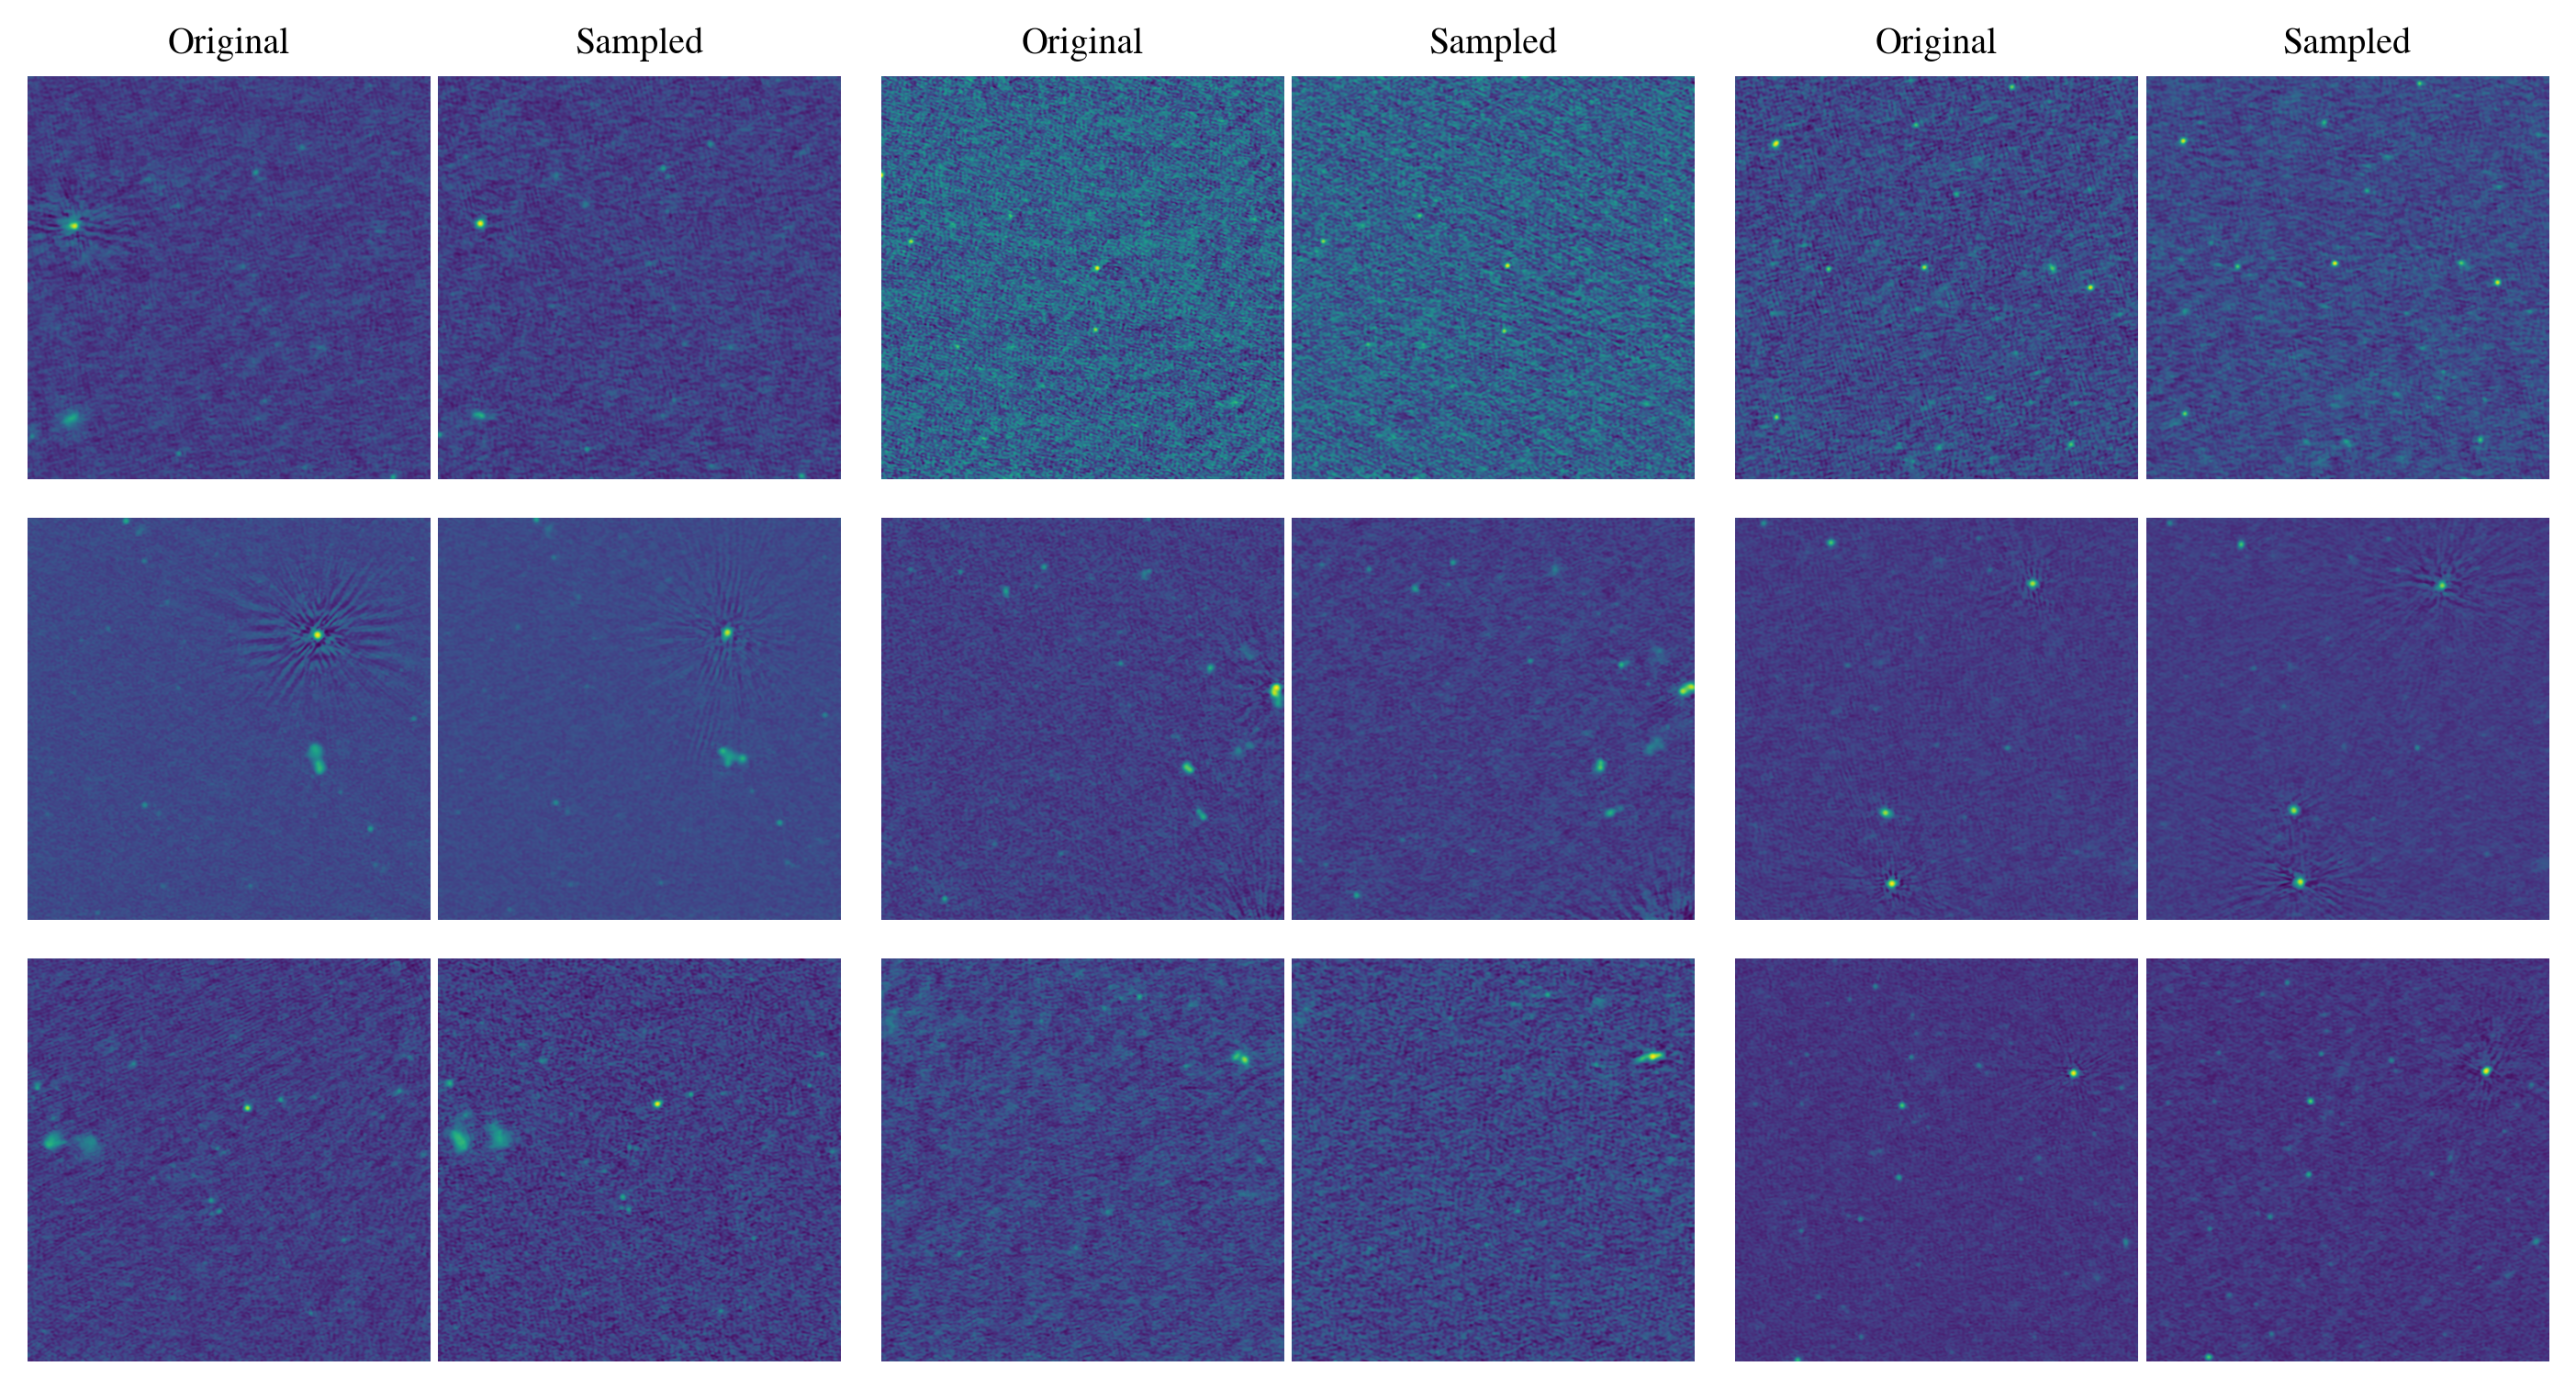

In [37]:
original_imgs = original_imgs.reshape(-1, *original_imgs.shape[-2:])
original_imgs_scaled = scaler.scale(original_imgs)
# sampled_imgs = sampled_imgs.reshape(-1, *sampled_imgs.shape[-2:])

n_examples = 9
seed = 67
rng = np.random.default_rng(seed)
example_idxs = rng.choice(len(sampled_imgs), size=n_examples, replace=False)
# example_idxs = range(n_examples)
n_col = 3

fig_width = 300 * mm
fig = plt.figure(
    figsize=(fig_width, (fig_width / n_col / 2 + 2 * mm) * n_examples / n_col),
    constrained_layout=False,
    dpi=300,
)
outer = fig.add_gridspec(
    n_examples // n_col, n_col, hspace=0.05, wspace=0.05
)  # spacing between pairs

for i, i_example in enumerate(example_idxs):
    inner = outer[i].subgridspec(1, 2, wspace=0.02)  # small gap inside pair
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])

    smpl = sampled_imgs[i_example].squeeze()
    orig = original_imgs_scaled[i_example]
    vmin = min(smpl.min(), np.nanmin(orig))
    vmax = max(smpl.max(), np.nanmax(orig))

    im_kw = dict(vmin=vmin, vmax=vmax, cmap="viridis")

    ax1.imshow(orig, **im_kw)
    ax2.imshow(smpl, **im_kw)

    ax1.axis("off")
    ax2.axis("off")

    if i < n_col:
        ax1.set_title("Original")
        ax2.set_title("Sampled")


# fig.show()
fig.canvas.draw()
custom_kw = dict(bbox_inches="tight")
fig.show()

# SWIIT Examples

Load run result

In [10]:
from glori.analysis.ldm.io import load_sampling_result

run_name = "fat-interval"

res = load_sampling_result(run_name)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

 15:13:35 (glori.analysis.ldm.io) - INFO : Loading results for <fat-interval>...
Loading original BDSF results: 100%|██████████| 64/64 [00:01<00:00, 45.63it/s]
 15:13:38 (glori.analysis.ldm.io) - INFO : Done.


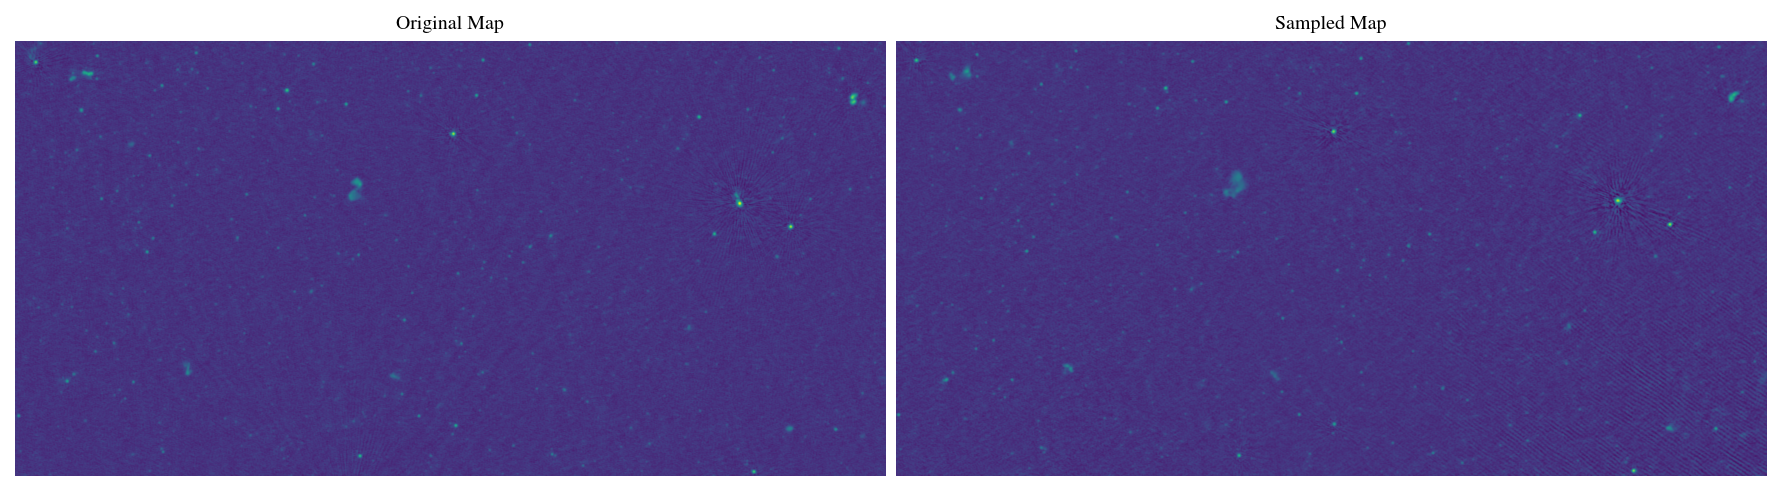

In [26]:
from glori.plotting.images import plot_image_grid

# Results section
original_imgs_scaled = scaler.scale(original_imgs).reshape(
    -1, *original_imgs.shape[-2:]
)
i_examples = [
    # 15,
    27
]

fig_width = 300 * mm

for i_example in i_examples:

    orig = original_imgs_scaled[i_example]
    smpl = sampled_imgs[i_example]

    vmax = max(np.nanmax(orig), np.nanmax(smpl))
    vmin = min(np.nanmin(orig), np.nanmin(smpl))

    fig, axs = plot_image_grid(
        [orig, smpl],
        n_cols=2,
        figsize=(fig_width, fig_width / 2),
        vmax=vmax,
        vmin=vmin,
    )
    axs[0].set_title("Original Map")
    axs[1].set_title("Sampled Map")

    fig.show()

# Catalog Context

## Imports, Definitions and Loads

Required imports and functions

In [27]:
from glori.plotting.maps import plot_sky_map
from glori.data.load import load_fits_image, load_mosaic

from glori.data.obs.micromaps.utils import (
    get_micromap_centers,
    get_micromaps,
    context_map_by_wcs,
    single_micromap_cutout,
    reduce_context_map,
    filter_catalog_by_wcs,
)
import pandas as pd


# Convenience function for loading mosaic names
# with control over random seed, number and max beam size
def load_mosaic_names(n_mosaics=1, seed=None, max_beam_arcsec=None):
    # Get list of mosaics based on directory contents
    mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])

    # Filter by max beam if specified
    if max_beam_arcsec is not None:
        # Load pointing info, which includes beam sizes
        pointing_info_df = pd.read_csv(
            paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
        )
        # Select good pointings, i.e. pointings with beam <= max_beam_arcsec
        good_pointings = np.array(
            pointing_info_df.index[
                pointing_info_df["Beam"] <= np.round(max_beam_arcsec / 3600, 5)
            ],
            dtype=np.str_,
        )
        # Filter mosaics by good pointings
        select_idxs = np.argwhere([p in good_pointings for p in mosaic_list]).flatten()
        mosaic_list = [mosaic_list[i] for i in select_idxs]
        # Pick randomly from remaining mosaics
        np.random.seed(seed)
        mosaics = [np.random.choice(mosaic_list) for _ in range(n_mosaics)]
        return mosaics

Settings

In [28]:
max_beam_arcsec = 6
seed = 42

# Output settings
output_dir = output_parent / "Dataset_generation"
if not output_dir.exists():
    output_dir.mkdir(parents=True)

Load catalog

In [29]:
# Load LoTSS DR3 catalog
from glori.data.load import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        # "Mosaic_ID",
    ]
)

Load pixel scaler

In [30]:
from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

# Image and Context Example Plots

In [31]:
# Load mosaic image
mosaic = "P168+15"
map_arr, wcs = load_mosaic(mosaic)

# Load context
ctxt_map, _ = context_map_by_wcs(wcs, lotss_cat, scale_output=False)

# Get cutouts
micromap_size = 1024
map_arr_scaled = scaler.scale(map_arr)
mmaps, centers, wcss = get_micromaps(map_arr_scaled, micromap_size, wcs=wcs)

Micromaps: 100%|██████████| 48/48 [00:00<00:00, 171.37micromap/s]


In [32]:
# Pick one as example
i_mmap = 30
mmap = mmaps[i_mmap]
center = centers[i_mmap]
wcs_mmap = wcss[i_mmap]

# Get context
ctxt = single_micromap_cutout(
    ctxt_map.transpose(1, 2, 0),
    micromap_size,
    center,
)[
    0
].transpose(2, 0, 1)

# Reduce for plotting
f_downscale = 16
ctxt = reduce_context_map(ctxt, f_downscale=f_downscale)

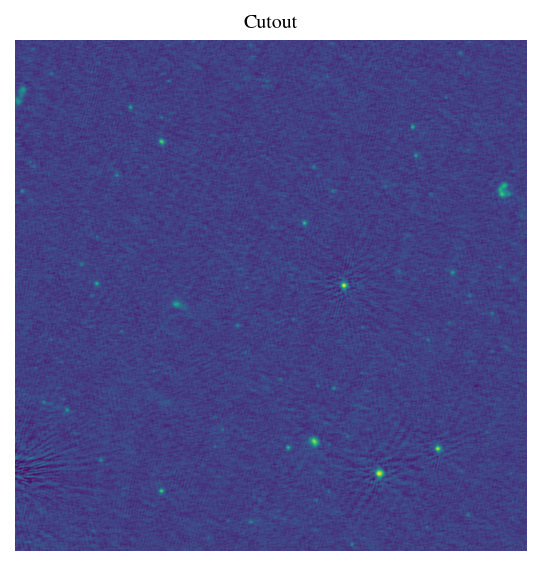

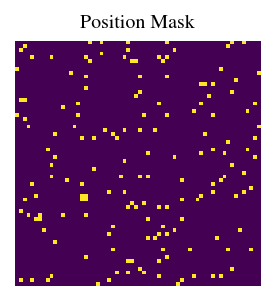

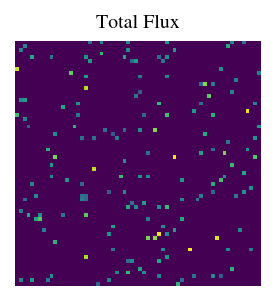

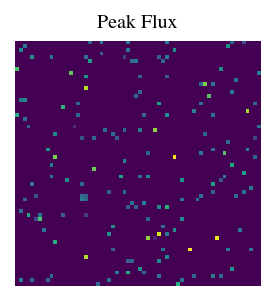

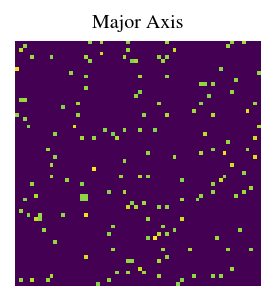

In [34]:
fig_width = 180 * mm

# Plot micromap cutout
fig, ax = plot_image_grid(
    [mmap],
    figsize=(fig_width * 0.5, fig_width * 0.5 * 1.2),
    origin="lower",
)

# Set title
ax.set_title("Cutout")


def log1p_n(x, n):
    for _ in range(n):
        x = np.log1p(x)
    return x


# Plot context
for ctxt_arr in [ctxt]:
    titles = ["Position Mask", "Total Flux", "Peak Flux", "Major Axis"]
    for i, ch in enumerate(ctxt_arr):
        fig, ax = plot_image_grid(
            [log1p_n(ch, 4)],
            n_cols=1,
            figsize=(fig_width / 4, fig_width * 1.2 / 4),
            origin="lower",
        )
        title = titles[i]

        ax.set_title(title)
        fig.show()